# Compare Residue Distances (v2)

This notebook is a streamlined replacement for `Compare_Residue_Distances.ipynb`.

Key differences vs v1:
- No `set_manual` branching.
- One **config JSON** per analysis variable stored *alongside* cached per-simulation CSVs.
- Intermediate per-simulation CSVs are treated as a **cache** (distance calculations are only performed when CSVs are missing, unless you force recompute).

Expected inputs:
- A trajectory **index CSV** with at least: `sim_number`, `sim_description`, `psf_path`, `dcd_path`, `time_factor`.

Outputs (written to `out_dir`):
- `{short_var_name}_config.json`
- `{sim}_{short_var_name}.csv` (cached distances)
- `SUMMARY_{short_var_name}.csv` (summary stats)
- Plots (optional, if you run plotting sections)


In [1]:
# Parameters (edit this cell)

import os
import sys
from pathlib import Path

# Default paths strategy (no GUI):
# - Prefer explicit environment variables (good for GitHub + HPC)
# - Otherwise, fall back to your local manuscript defaults *if they exist*
# - Otherwise, fall back to repo-relative paths

# Try to infer repo root (expects a `src/` folder at the repo root).
_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv("MD_REPO_ROOT", _cwd)).resolve()

SRC_DIR = REPO_ROOT / "src"
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# 1) Index CSV
if "MD_INDEX_CSV" in os.environ:
    INDEX_CSV = Path(os.environ["MD_INDEX_CSV"]).expanduser().resolve()
else:
    _candidates = [
        Path(r"D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/Anton_SimulationIndex20260413.csv"),
        REPO_ROOT / "data" / "trajectory_index.csv",
    ]
    INDEX_CSV = next((p.resolve() for p in _candidates if p.exists()), _candidates[-1].resolve())

# 2) Output root
# If you point OUT_ROOT at your existing manuscript folder, the notebook will *reuse* cached CSVs.
# The default below uses the directory containing the index CSV (common in your current layout).
OUT_ROOT = Path(os.getenv("MD_OUT_ROOT", INDEX_CSV.parent)).expanduser().resolve()

# Simulations to load
SIM_LIST = None  # set to a list like ['14', '14b', 'A'] or leave None to load all

# Cache behavior
FORCE_RECOMPUTE = False

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"SRC_DIR:   {SRC_DIR}")
print(f"INDEX_CSV: {INDEX_CSV}")
print(f"OUT_ROOT:  {OUT_ROOT}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")


REPO_ROOT: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics
SRC_DIR:   D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\src
INDEX_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
OUT_ROOT:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript
FORCE_RECOMPUTE: False


In [2]:
# Imports (v2)

import numpy as np
import pandas as pd

# v2: use extracted, non-GUI helpers (not MYT_functions)
from traj_utils import validate_traj_index, read_trajectories
from plotting import plot_dist_time_trace_hist

from distance_analysis import (
    DistanceAnalysisConfig,
    PlotStyle,
    compute_distance_csvs,
    load_or_create_config,
    make_summary_table,
)


In [3]:
# Load index CSV and trajectories

valid_df = validate_traj_index(str(INDEX_CSV))

all_sims = list(valid_df["sim_number"].astype(str).values)
sim_list = all_sims if SIM_LIST is None else [str(s) for s in SIM_LIST]

u_list, label_list, tf_list = read_trajectories(valid_df, sim_list)


Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.dcd
Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.dcd
D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
reading: 8
8: 4202 frames, 1008.48 ns
reading: 14
14: 4200 frames, 1008.0 ns
reading: 14b
14b: 4200 frames, 1008.0 ns
reading: 15
15: 4200 frames, 1008.0 ns
reading: 15b
15b: 4200 frames, 100

c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\topology\PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


34: 1000 frames, 100.0 ns
reading: 35


c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\topology\PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


35: 1000 frames, 100.0 ns
reading: A
A: 4177 frames, 1002.48 ns
reading: B
B: 4187 frames, 1004.88 ns
reading: C
C: 4167 frames, 1000.0799999999999 ns
reading: D
D: 4182 frames, 1003.68 ns
reading: E
E: 4174 frames, 1001.76 ns
reading: F
F: 4181 frames, 1003.4399999999999 ns
reading: 17ext
17ext: 2489 frames, 2986.7999999999997 ns
reading: 38
38: 2480 frames, 2976.0 ns
reading: 42
42: 3310 frames, 3972.0 ns
reading: 43
43: 3310 frames, 3972.0 ns
reading: 43b
43b: 1660 frames, 1992.0 ns
reading: 43c
43c: 1660 frames, 1992.0 ns
reading: 45_noW
45_noW: 3340 frames, 4008.0 ns
reading: 45b_noW
45b_noW: 840 frames, 1008.0 ns
reading: 45c_noW
45c_noW: 840 frames, 1008.0 ns
reading: 46_noW
46_noW: 1670 frames, 2004.0 ns
reading: 46b_noW
46b_noW: 840 frames, 1008.0 ns
reading: 46c_noW
46c_noW: 840 frames, 1008.0 ns
reading: 48_noW
48_noW: 420 frames, 504.0 ns
reading: 53
53: 840 frames, 1008.0 ns
reading: 54
54: 830 frames, 996.0 ns
reading: 58
58: 840 frames, 1008.0 ns


In [34]:
# Define or load analysis config
#
# Key idea: `resolve_out_dir` will reuse an existing cache folder even if its
# name doesn't match `short_var_name`, by scanning OUT_ROOT and its immediate
# subfolders for:
# - `{short_var_name}_config.json`
# - legacy metadata JSON containing `short_var_name`
# - cached CSVs like `*_{short_var_name}.csv`

from distance_analysis import resolve_out_dir

short_var_name = "FtsW_W138-R145 stacking"

# Optional override if you want to force a specific legacy folder.
OUT_DIR_OVERRIDE = None
# Example:
# OUT_DIR_OVERRIDE = r"D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/FtsW_K370_L198_Ca_dist"

out_dir = Path(
    resolve_out_dir(
        out_root=str(OUT_ROOT),
        short_var_name=short_var_name,
        out_dir_override=OUT_DIR_OVERRIDE,
        prefer_existing=True,
    )
).resolve()

print(f"Resolved out_dir: {out_dir}")

default_cfg = DistanceAnalysisConfig(
    var_name="FtsW W138 - R145 stacking",
    short_var_name=short_var_name,
    res1="(segid PROD PAG1 PAU1) and resid 138 and (name CD2)",
    res2="(segid PROD PAG1 PAU1) and resid 145 and (name CZ)",
    dist_type="any",
    plot_list=sim_list,
    out_dir=str(out_dir),
    x_cutoff=4.5,
    plot_style=PlotStyle(
        share_lim=True,
        x_min_shared=0.0,
        x_max_shared=15.0,
        max_hist=0.4,
        scale=2.6,
        var_name_plot=None,
    ),
)

cfg, cfg_path = load_or_create_config(
    out_dir=str(out_dir),
    short_var_name=short_var_name,
    default=default_cfg,
    overwrite=False,
)

print(f"Config path: {cfg_path}")
print(f"Output dir:  {cfg.out_dir}")
print(f"Sims:        {len(cfg.plot_list)}")


Resolved out_dir: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking
Config path: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\FtsW_W138-R145 stacking_config.json
Output dir:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking
Sims:        31


In [35]:
# Compute (or reuse cached) per-simulation CSVs

data_dict = compute_distance_csvs(
    cfg=cfg,
    sim_list=sim_list,
    u_list=u_list,
    tf_list=tf_list,
    force_recompute=FORCE_RECOMPUTE,
)

print(f"Cached CSVs available: {len(data_dict)}")
list(data_dict.items())[:3]  # preview


grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\8_FtsW_W138-R145 stacking.csv
grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\14_FtsW_W138-R145 stacking.csv
grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\14b_FtsW_W138-R145 stacking.csv
grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\15_FtsW_W138-R145 stacking.csv
grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\15b_FtsW_W138-R145 stacking.csv
grp1: 1 atoms
grp2: 1 atoms
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\17_FtsW_W138-R14

[('8',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_W138-R145 stacking\\8_FtsW_W138-R145 stacking.csv'),
 ('14',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_W138-R145 stacking\\14_FtsW_W138-R145 stacking.csv'),
 ('14b',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_W138-R145 stacking\\14b_FtsW_W138-R145 stacking.csv')]

In [36]:
# Summary table (fast; reads CSV cache)

summary_csv = Path(cfg.out_dir) / f"SUMMARY_{cfg.short_var_name}.csv"
summary_df = make_summary_table(data_dict, str(summary_csv), x_cutoff=cfg.x_cutoff)
summary_df.sort_values("sim_id").head(10)


,sim_id,csv_path,n_points,min,mean,std,stderr,max,fraction_below_cutoff,error
1,14,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,3.528082,5.363273,0.901509,0.013911,8.915358,0.160476,
2,14b,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,3.710658,7.026091,1.399719,0.021598,10.807742,0.043810,
3,15,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,4.051284,5.812533,0.574023,0.008857,8.022951,0.001667,
4,15b,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,3.506288,5.393326,0.772745,0.011924,9.844652,0.080952,
5,17,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,3.461101,7.237169,1.459622,0.022522,12.047444,0.046190,
13,17ext,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,2489,3.395099,6.385875,1.663325,0.033340,12.051155,0.100844,
6,19,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,3.386010,6.140564,1.385654,0.021381,9.317985,0.120000,
14,38,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,2480,3.099698,5.347890,1.219135,0.024481,10.594922,0.236694,
15,42,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,3310,3.465160,6.555158,1.126844,0.019586,10.467338,0.055589,
16,43,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,3310,3.392308,6.532393,0.830696,0.014439,10.911204,0.011480,


8: Min = 3.3 Å | Frame 459/4202 | Time 109.92 ns
8: Mean = 5.3 Å | Fraction < 4.5 Å = 10.54%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\8_FtsW_W138-R145 stacking.png


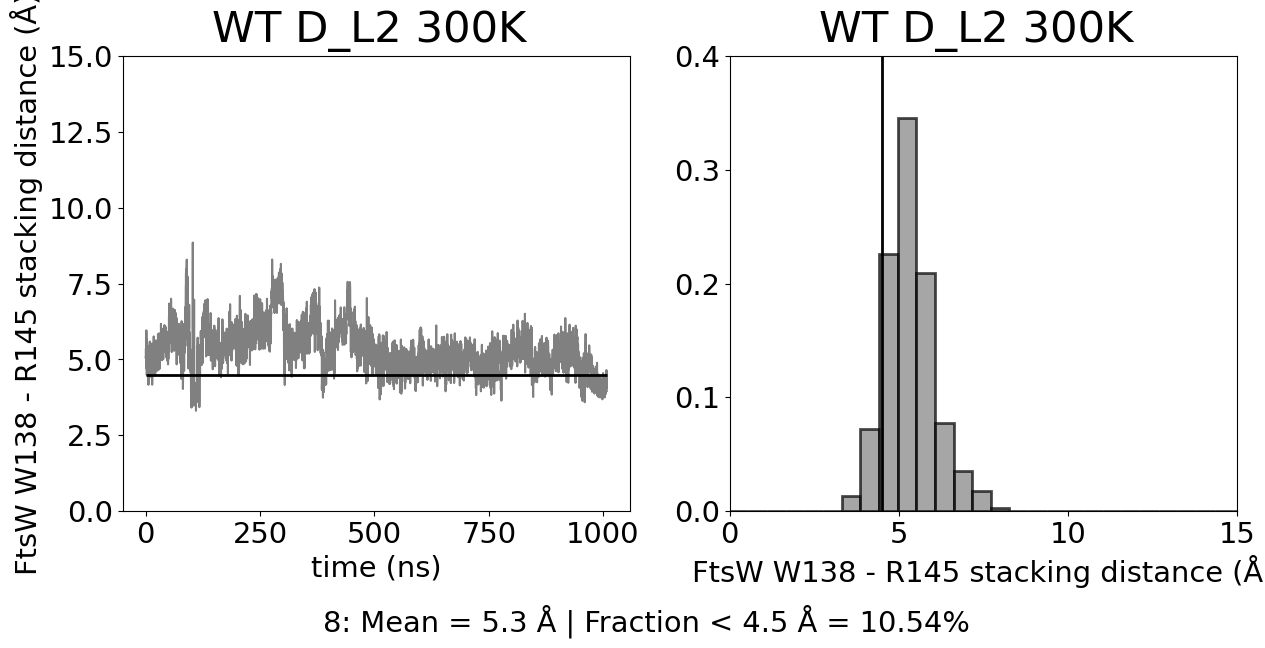

14: Min = 3.5 Å | Frame 3757/4200 | Time 901.44 ns
14: Mean = 5.4 Å | Fraction < 4.5 Å = 16.05%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\14_FtsW_W138-R145 stacking.png


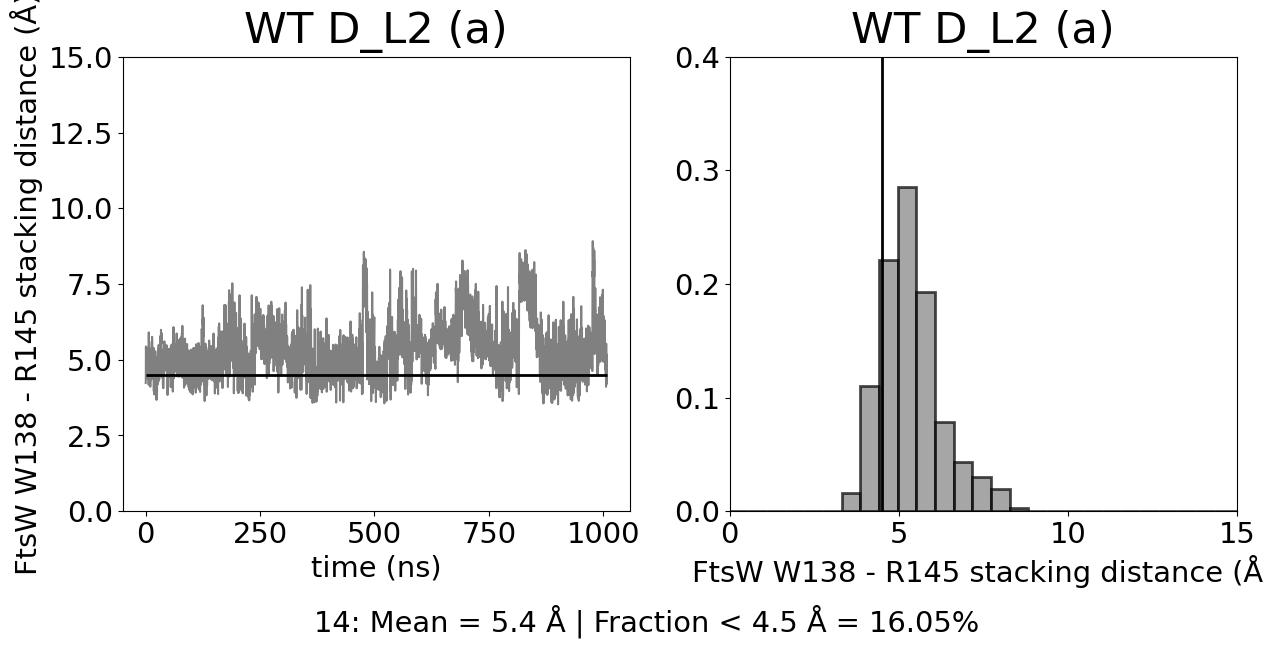

14b: Min = 3.7 Å | Frame 307/4200 | Time 73.44 ns
14b: Mean = 7.0 Å | Fraction < 4.5 Å = 4.38%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\14b_FtsW_W138-R145 stacking.png


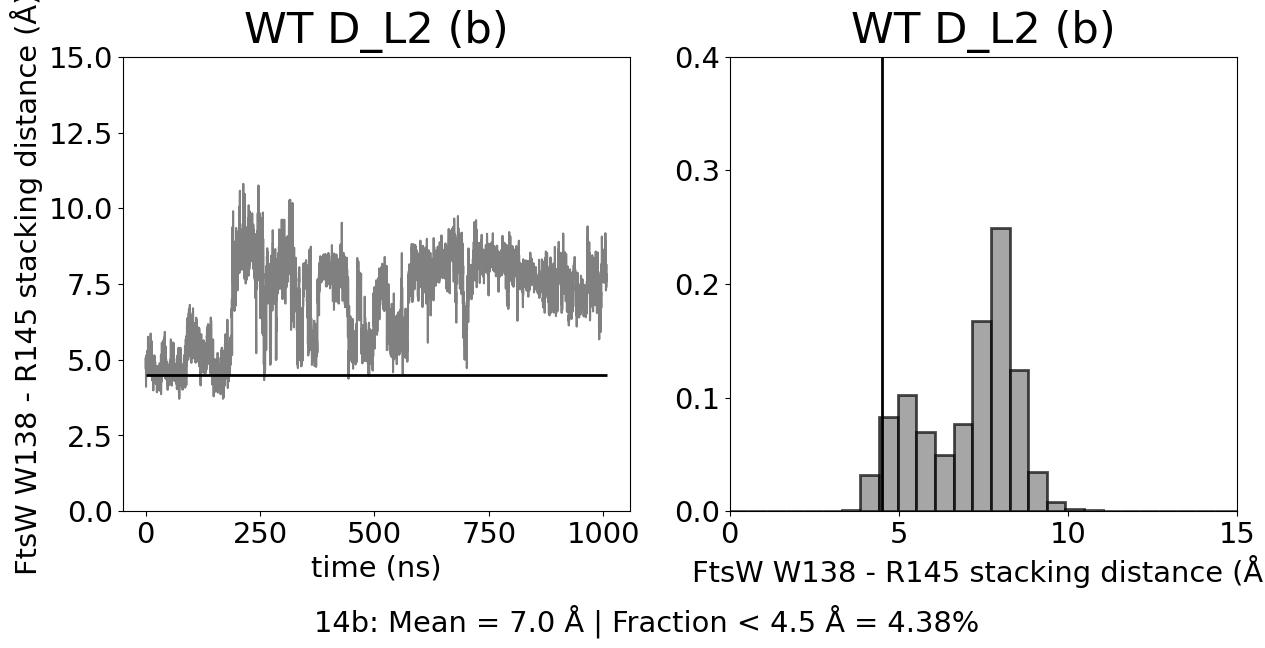

15: Min = 4.1 Å | Frame 981/4200 | Time 235.2 ns
15: Mean = 5.8 Å | Fraction < 4.5 Å = 0.17%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\15_FtsW_W138-R145 stacking.png


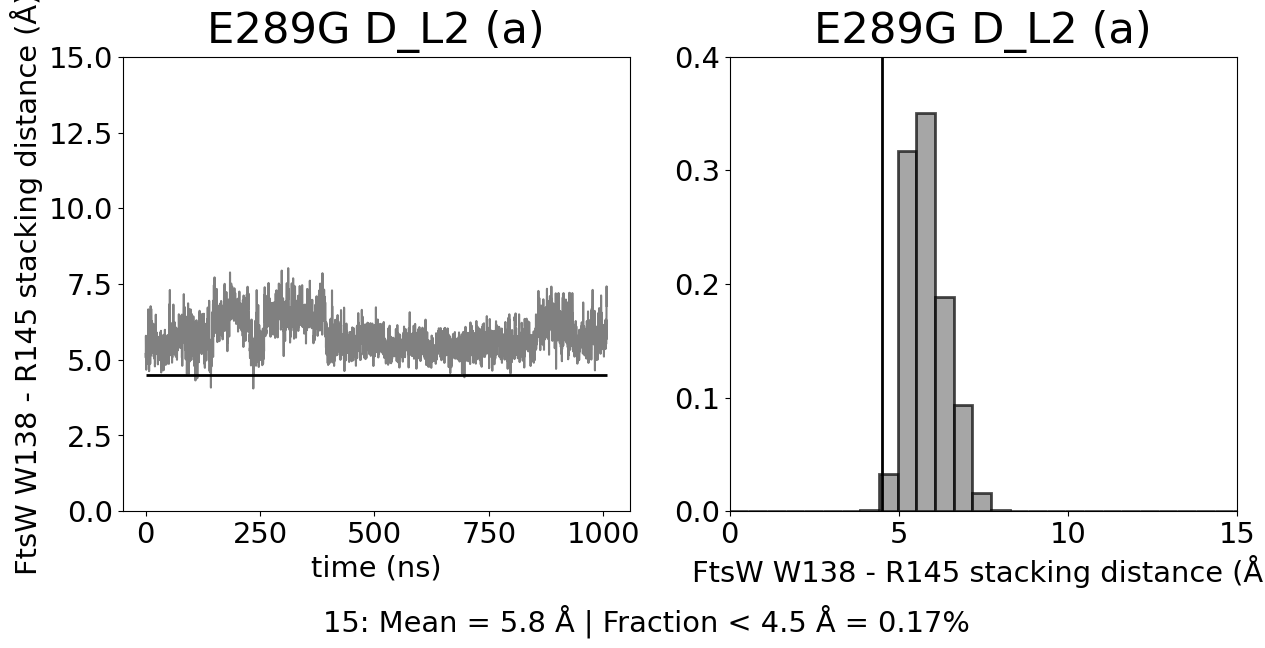

15b: Min = 3.5 Å | Frame 1709/4200 | Time 409.92 ns
15b: Mean = 5.4 Å | Fraction < 4.5 Å = 8.10%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\15b_FtsW_W138-R145 stacking.png


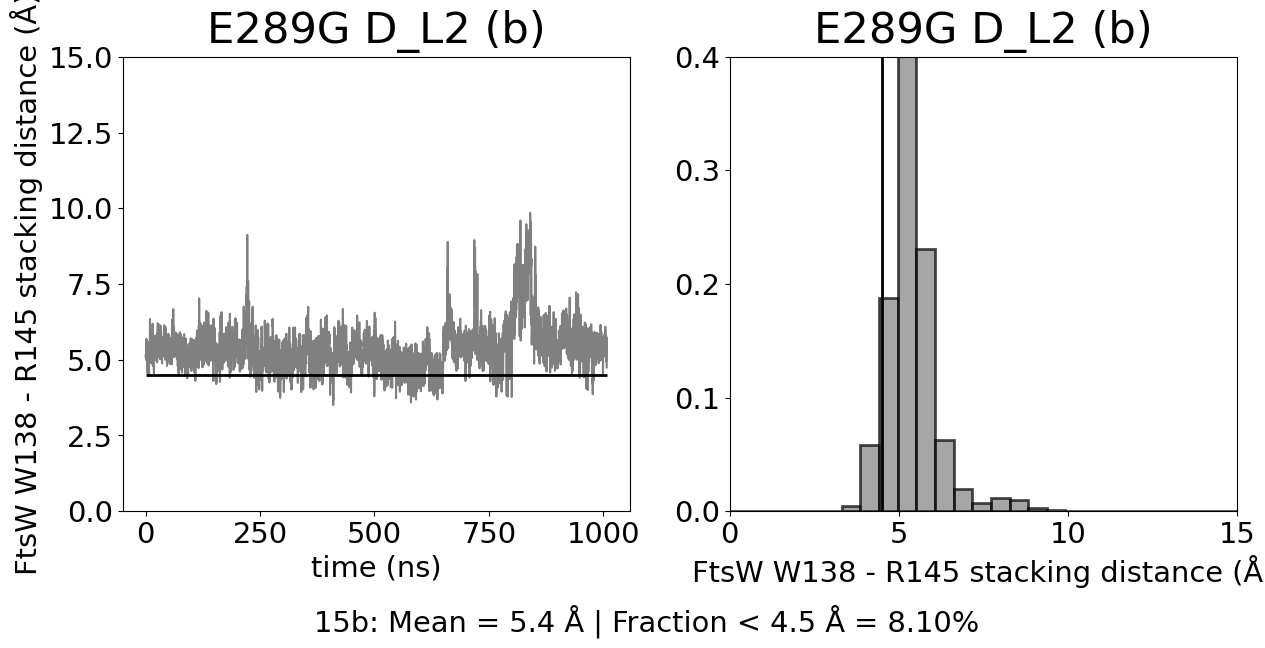

17: Min = 3.5 Å | Frame 282/4200 | Time 67.44 ns
17: Mean = 7.2 Å | Fraction < 4.5 Å = 4.62%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\17_FtsW_W138-R145 stacking.png


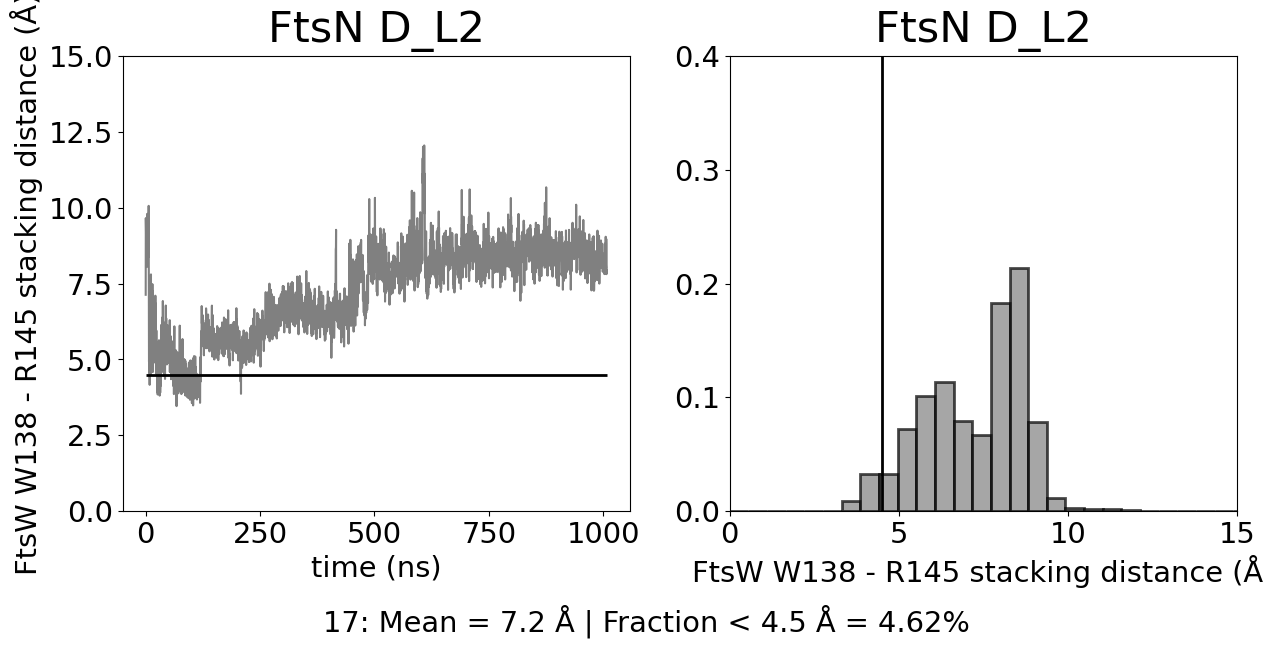

19: Min = 3.4 Å | Frame 3536/4200 | Time 848.4 ns
19: Mean = 6.1 Å | Fraction < 4.5 Å = 12.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\19_FtsW_W138-R145 stacking.png


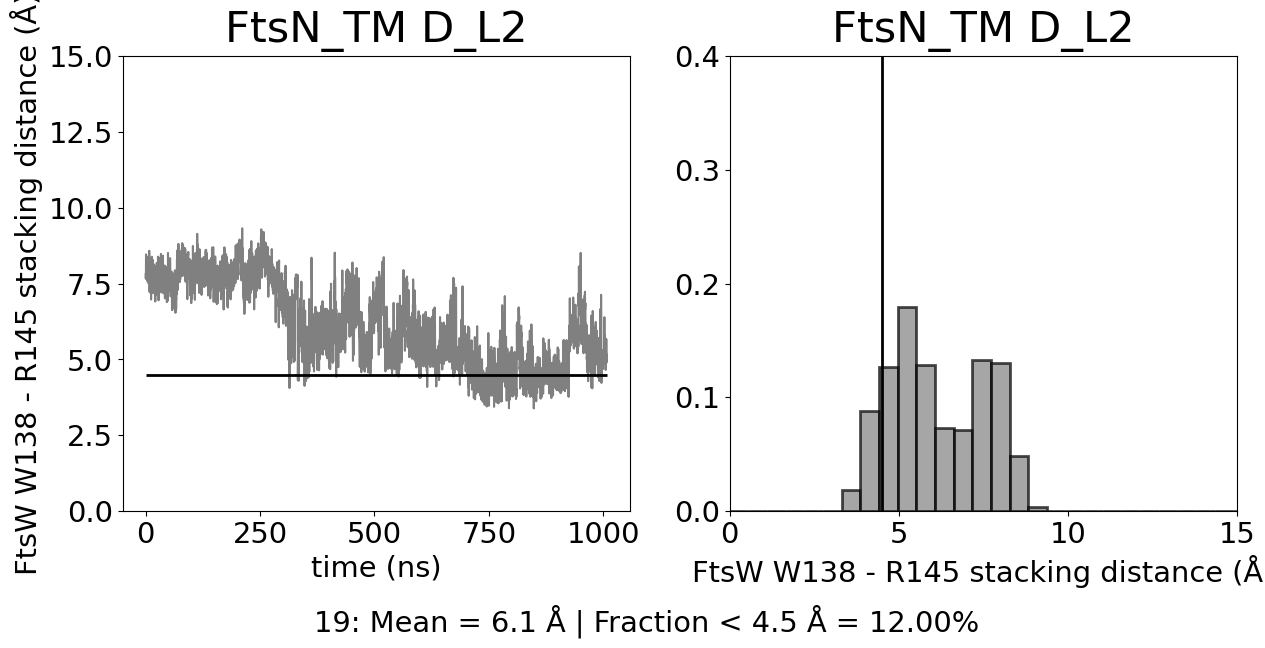

A: Min = 3.3 Å | Frame 2511/4177 | Time 602.4 ns
A: Mean = 5.3 Å | Fraction < 4.5 Å = 23.44%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\A_FtsW_W138-R145 stacking.png


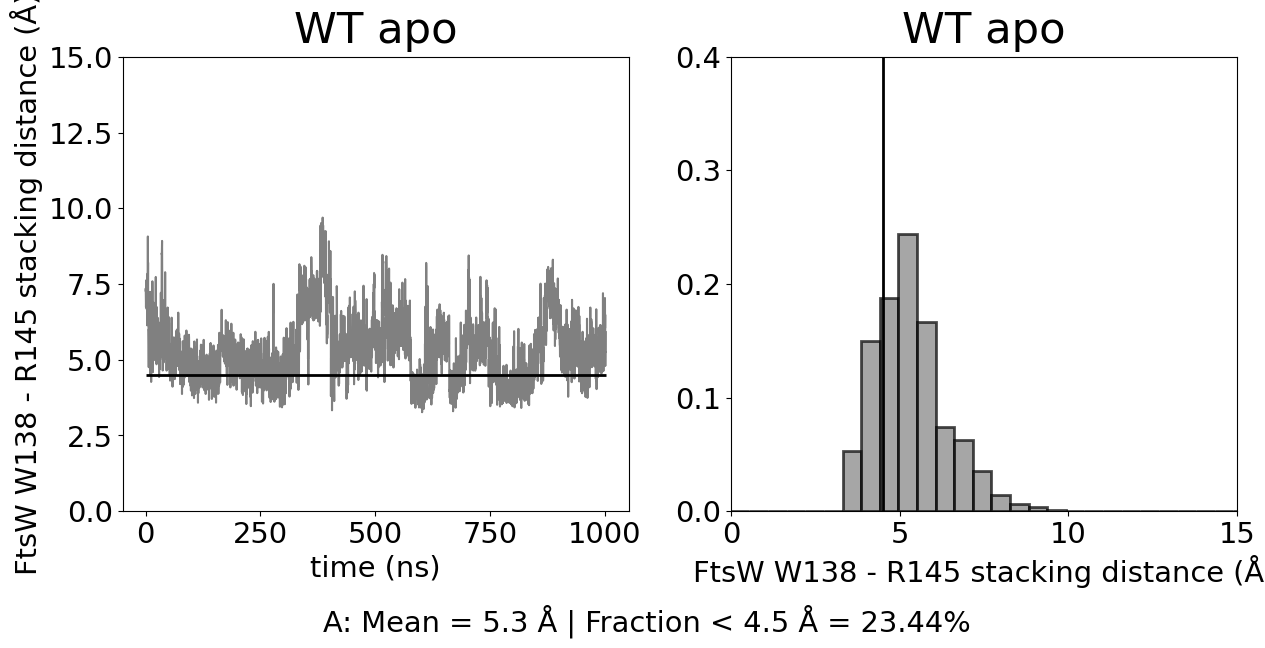

B: Min = 3.3 Å | Frame 1742/4187 | Time 417.84 ns
B: Mean = 5.4 Å | Fraction < 4.5 Å = 14.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\B_FtsW_W138-R145 stacking.png


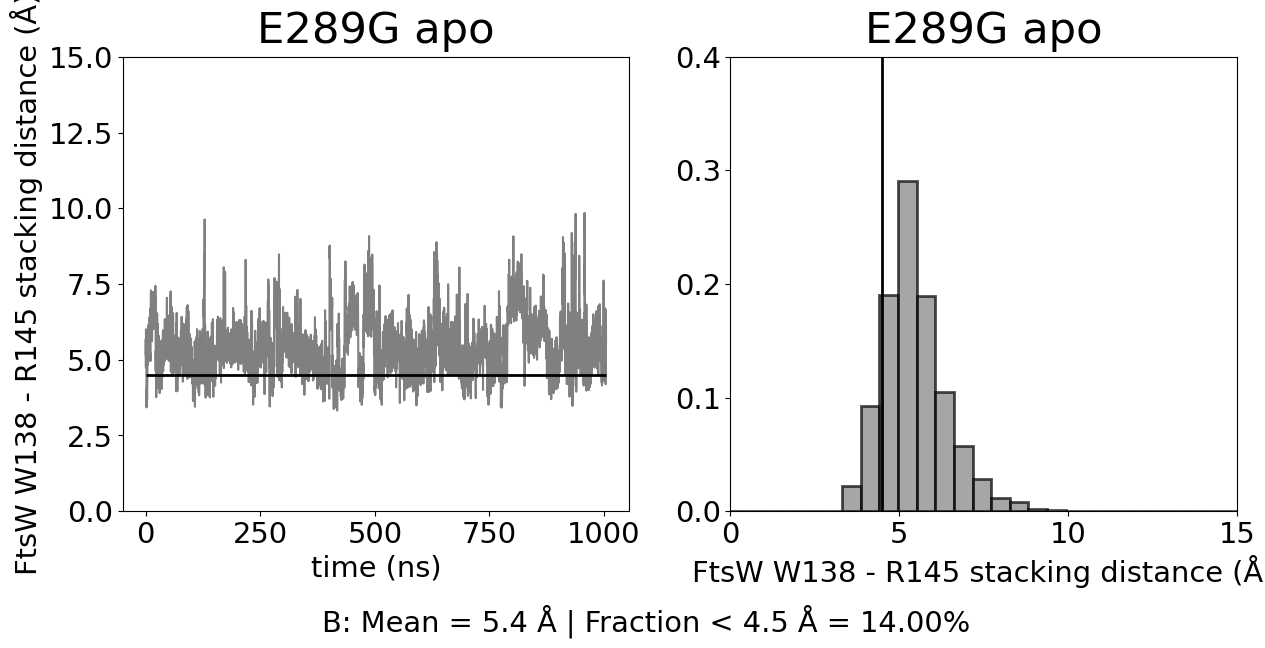

C: Min = 3.2 Å | Frame 3904/4167 | Time 936.72 ns
C: Mean = 5.2 Å | Fraction < 4.5 Å = 21.67%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\C_FtsW_W138-R145 stacking.png


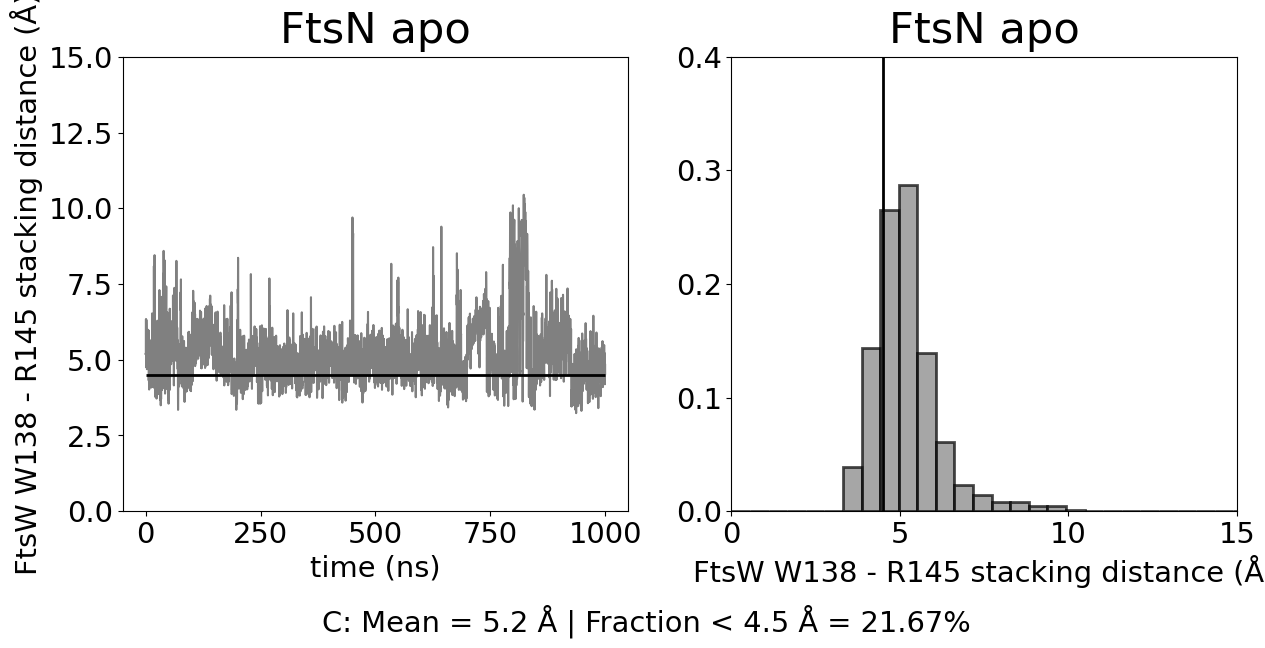

D: Min = 3.3 Å | Frame 148/4182 | Time 35.28 ns
D: Mean = 5.3 Å | Fraction < 4.5 Å = 19.01%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\D_FtsW_W138-R145 stacking.png


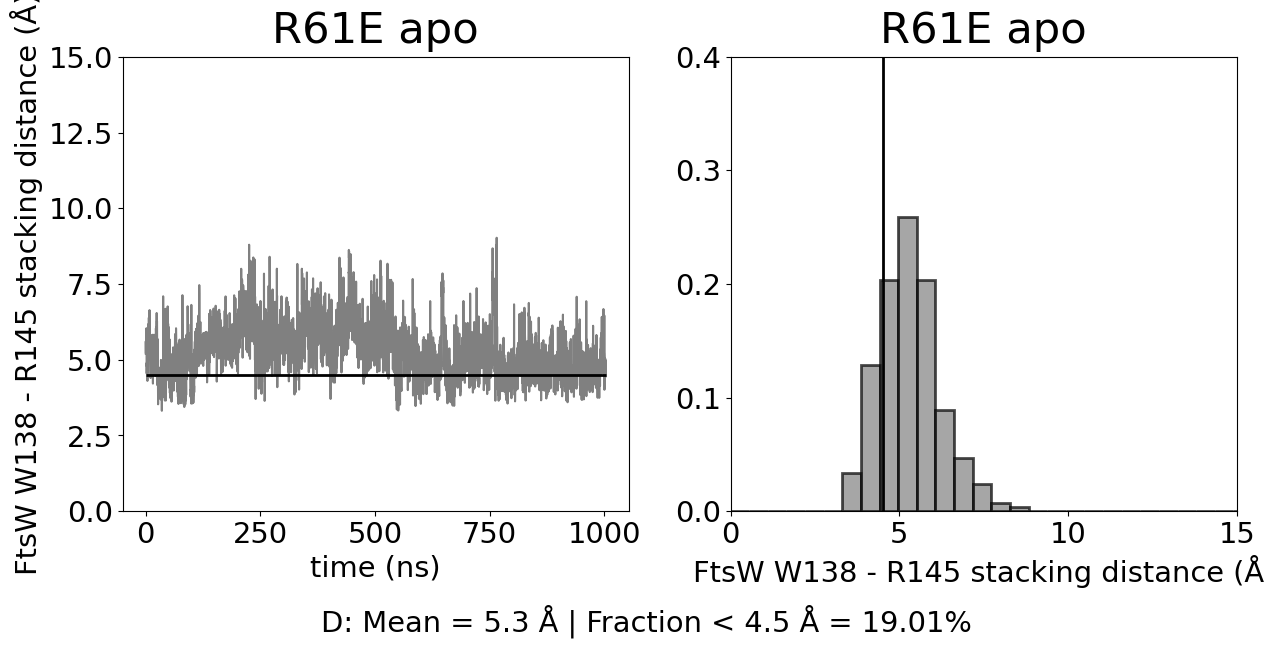

E: Min = 3.3 Å | Frame 294/4174 | Time 70.32 ns
E: Mean = 5.2 Å | Fraction < 4.5 Å = 25.23%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\E_FtsW_W138-R145 stacking.png


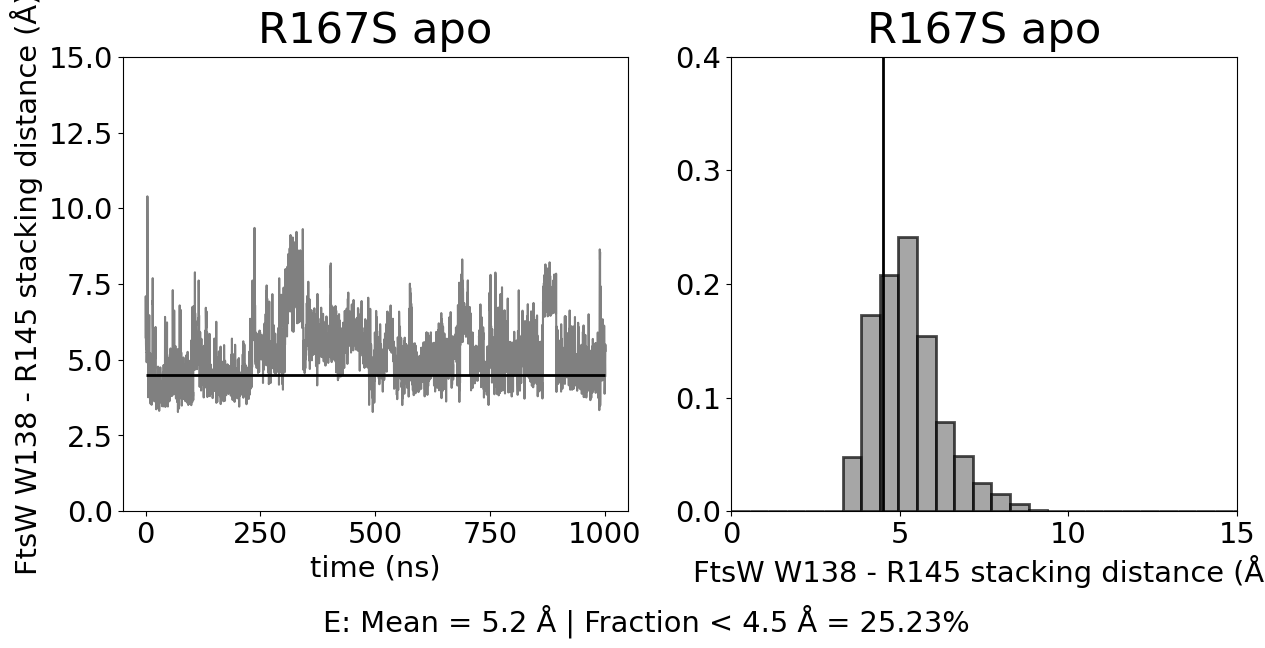

F: Min = 3.2 Å | Frame 1704/4181 | Time 408.72 ns
F: Mean = 4.9 Å | Fraction < 4.5 Å = 32.38%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\F_FtsW_W138-R145 stacking.png


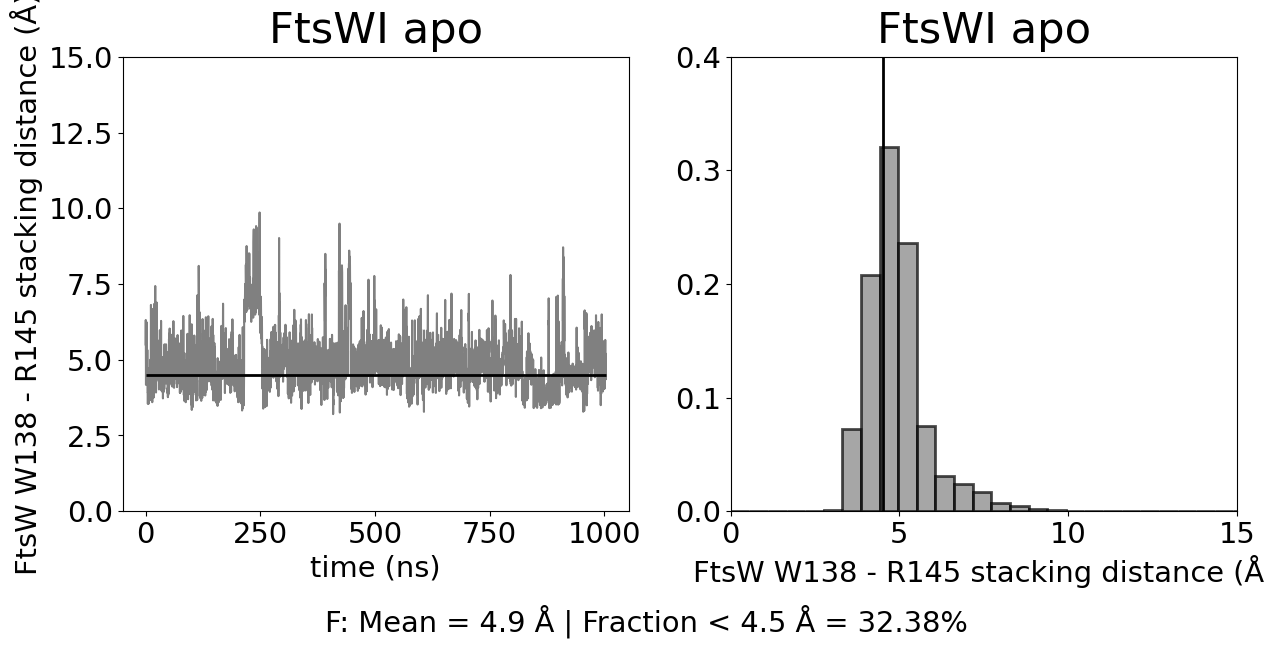

17ext: Min = 3.4 Å | Frame 2349/2489 | Time 2817.6 ns
17ext: Mean = 6.4 Å | Fraction < 4.5 Å = 10.08%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\17ext_FtsW_W138-R145 stacking.png


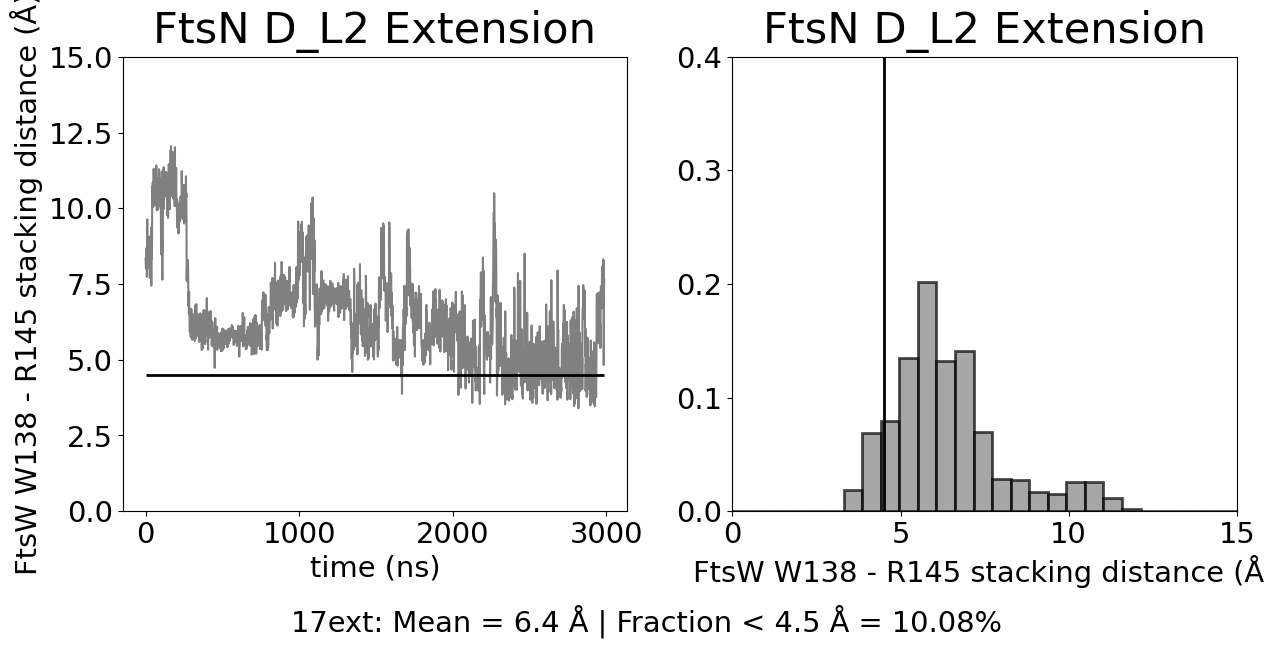

38: Min = 3.1 Å | Frame 505/2480 | Time 604.8 ns
38: Mean = 5.3 Å | Fraction < 4.5 Å = 23.67%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\38_FtsW_W138-R145 stacking.png


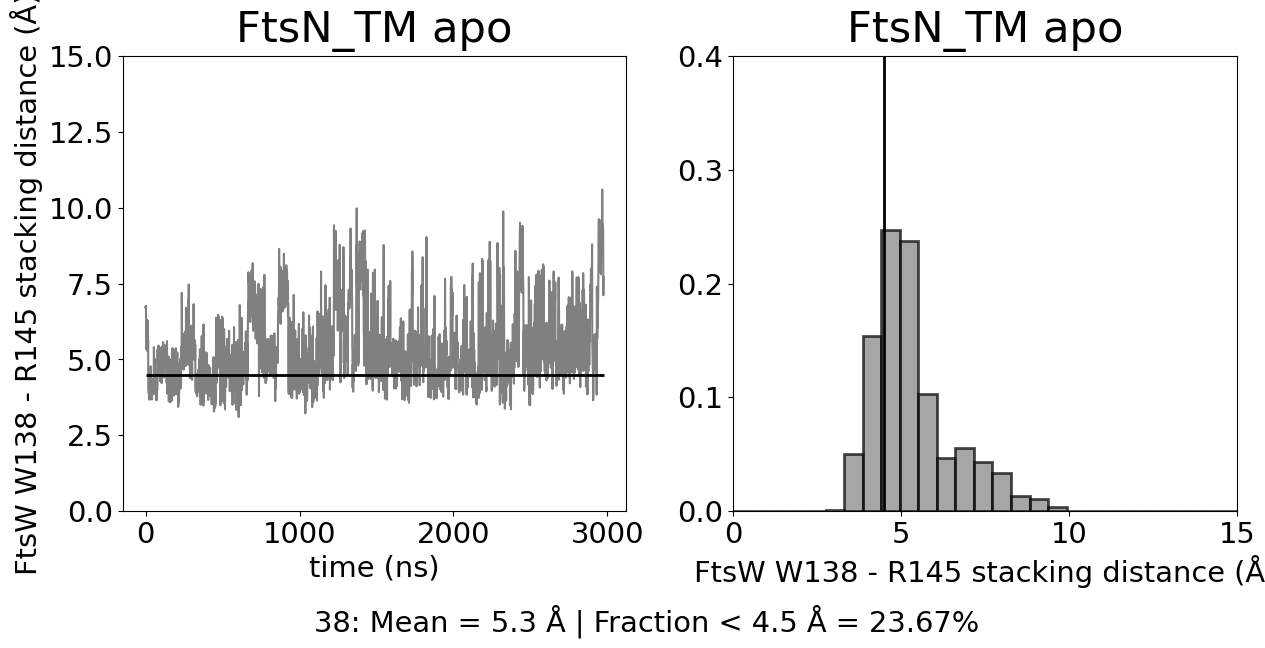

42: Min = 3.5 Å | Frame 2497/3310 | Time 2995.2 ns
42: Mean = 6.6 Å | Fraction < 4.5 Å = 5.56%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\42_FtsW_W138-R145 stacking.png


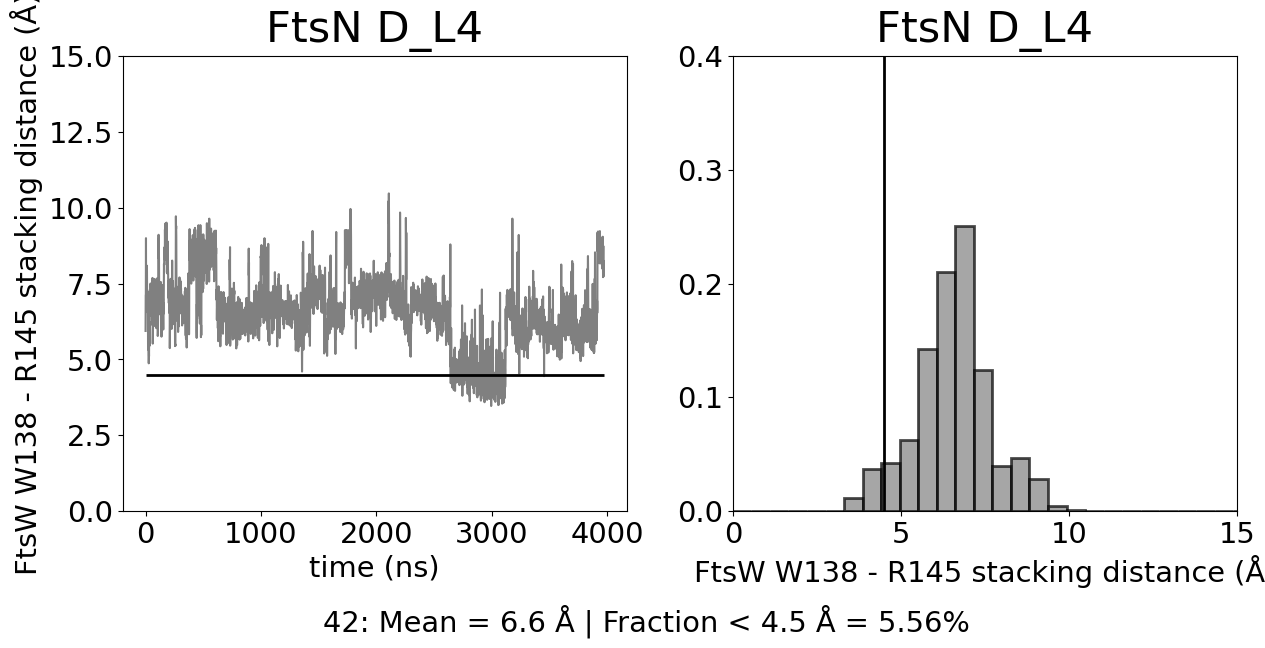

43: Min = 3.4 Å | Frame 2385/3310 | Time 2860.8 ns
43: Mean = 6.5 Å | Fraction < 4.5 Å = 1.15%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\43_FtsW_W138-R145 stacking.png


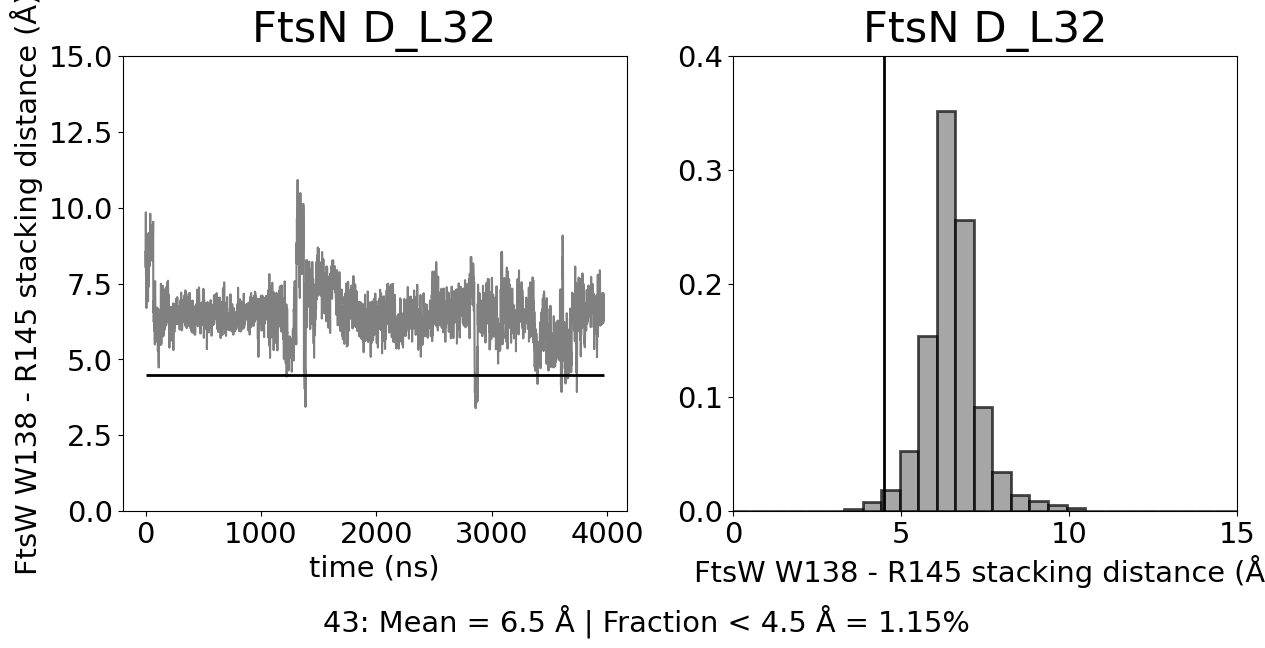

43b: Min = 4.6 Å | Frame 877/1660 | Time 1051.2 ns
43b: Mean = 6.9 Å | Fraction < 4.5 Å = 0.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\43b_FtsW_W138-R145 stacking.png


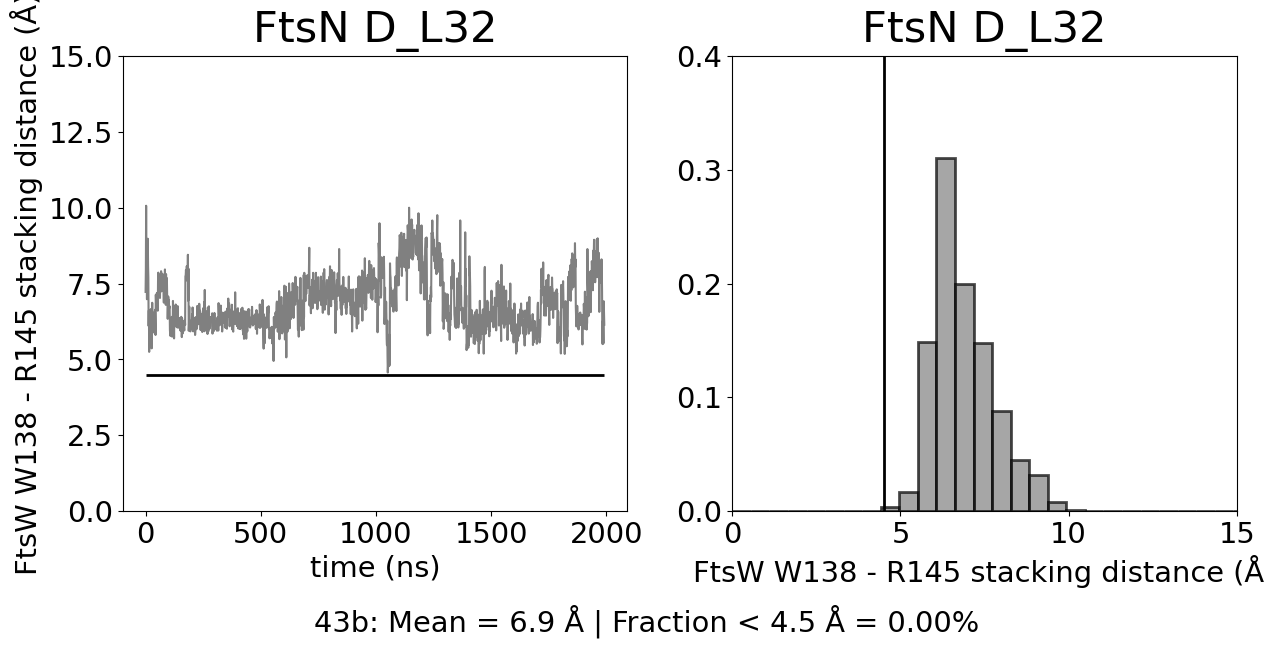

43c: Min = 3.9 Å | Frame 1215/1660 | Time 1456.8 ns
43c: Mean = 7.6 Å | Fraction < 4.5 Å = 0.12%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\43c_FtsW_W138-R145 stacking.png


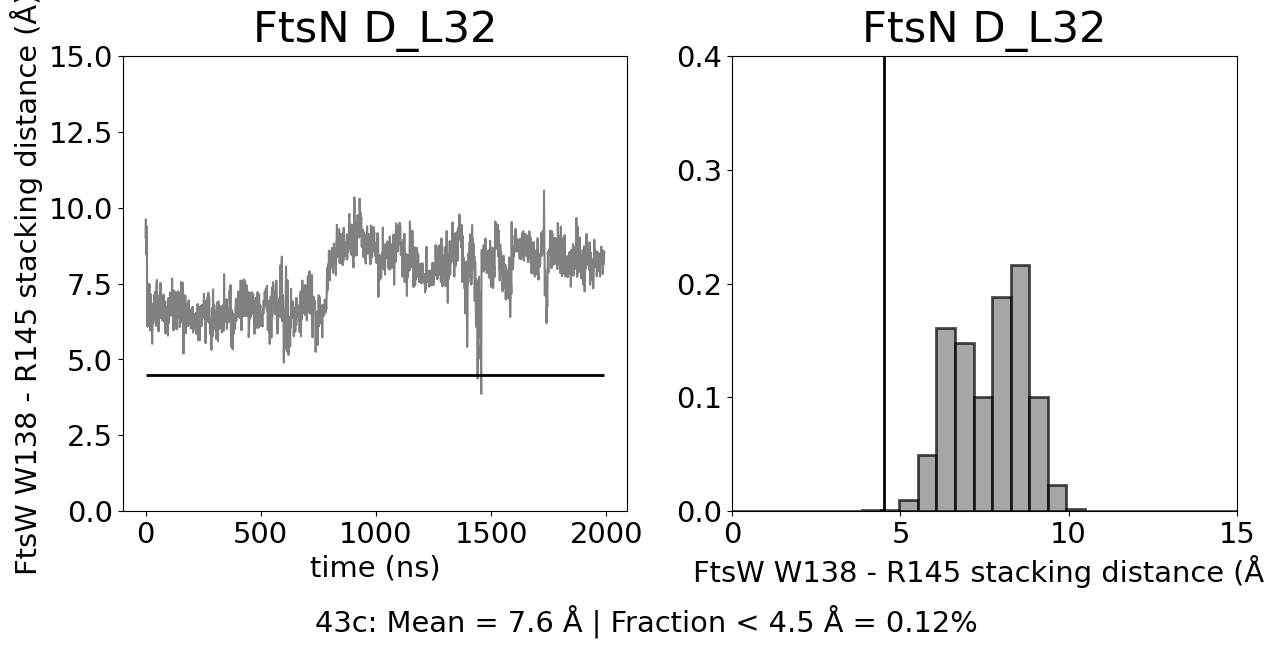

45: Min = 3.3 Å | Frame 1432/3340 | Time 1717.2 ns
45: Mean = 6.0 Å | Fraction < 4.5 Å = 10.39%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\45_noW_FtsW_W138-R145 stacking.png


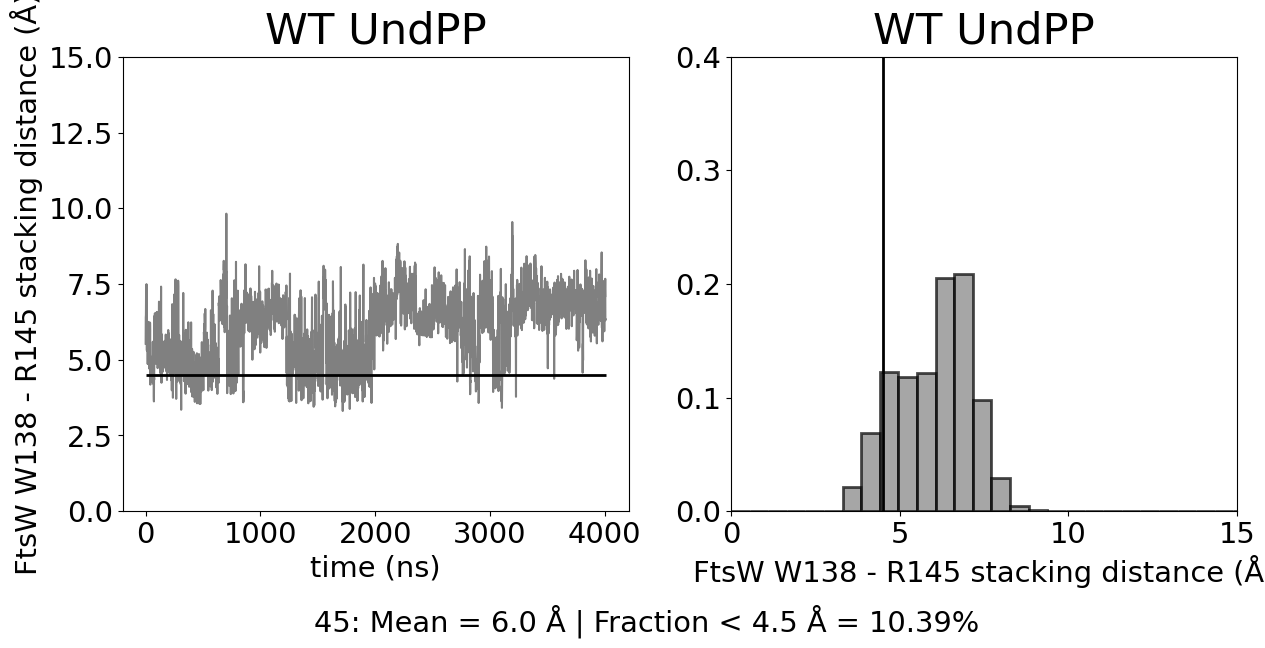

45b: Min = 3.4 Å | Frame 80/840 | Time 94.8 ns
45b: Mean = 6.1 Å | Fraction < 4.5 Å = 16.31%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\45b_noW_FtsW_W138-R145 stacking.png


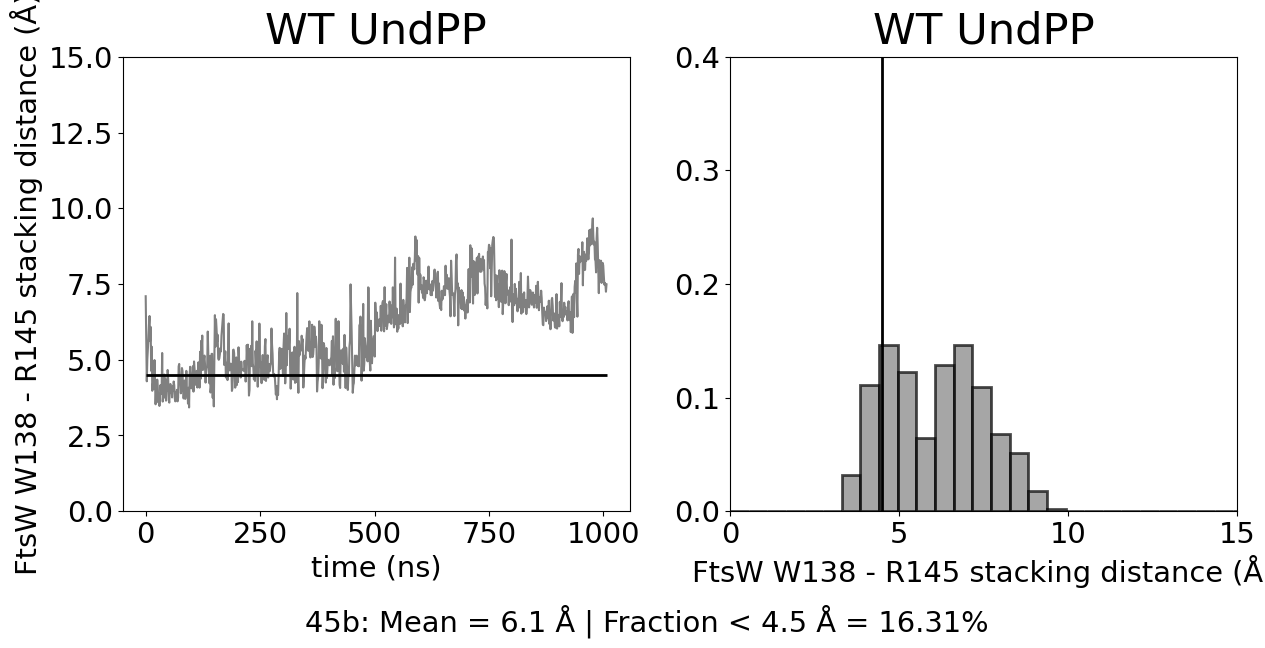

45c: Min = 3.3 Å | Frame 777/840 | Time 931.2 ns
45c: Mean = 6.9 Å | Fraction < 4.5 Å = 13.57%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\45c_noW_FtsW_W138-R145 stacking.png


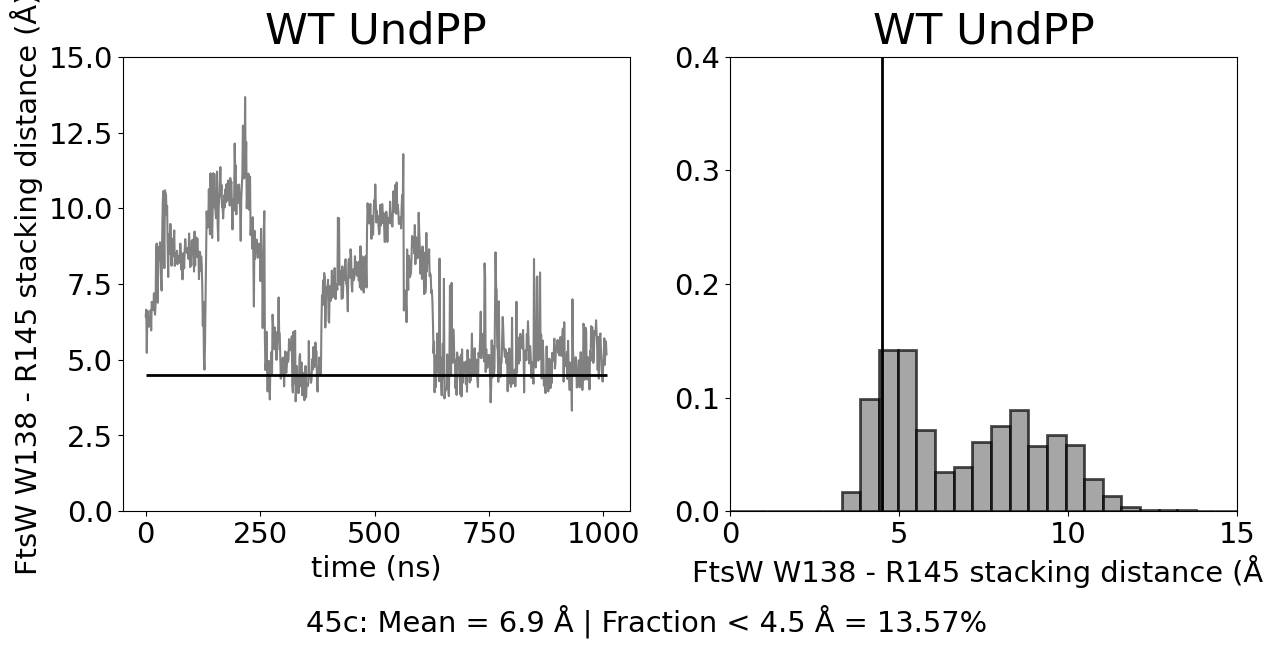

46: Min = 3.4 Å | Frame 17/1670 | Time 19.2 ns
46: Mean = 5.4 Å | Fraction < 4.5 Å = 19.58%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\46_noW_FtsW_W138-R145 stacking.png


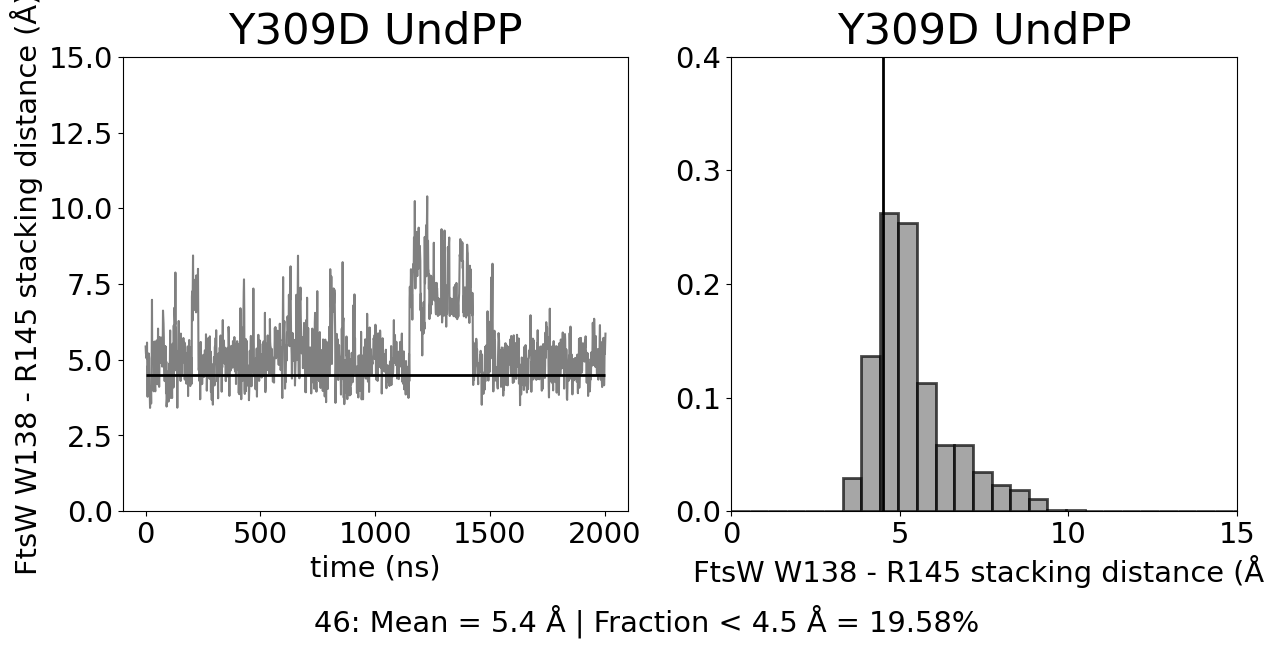

46b: Min = 3.5 Å | Frame 671/840 | Time 804.0 ns
46b: Mean = 5.4 Å | Fraction < 4.5 Å = 19.17%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\46b_noW_FtsW_W138-R145 stacking.png


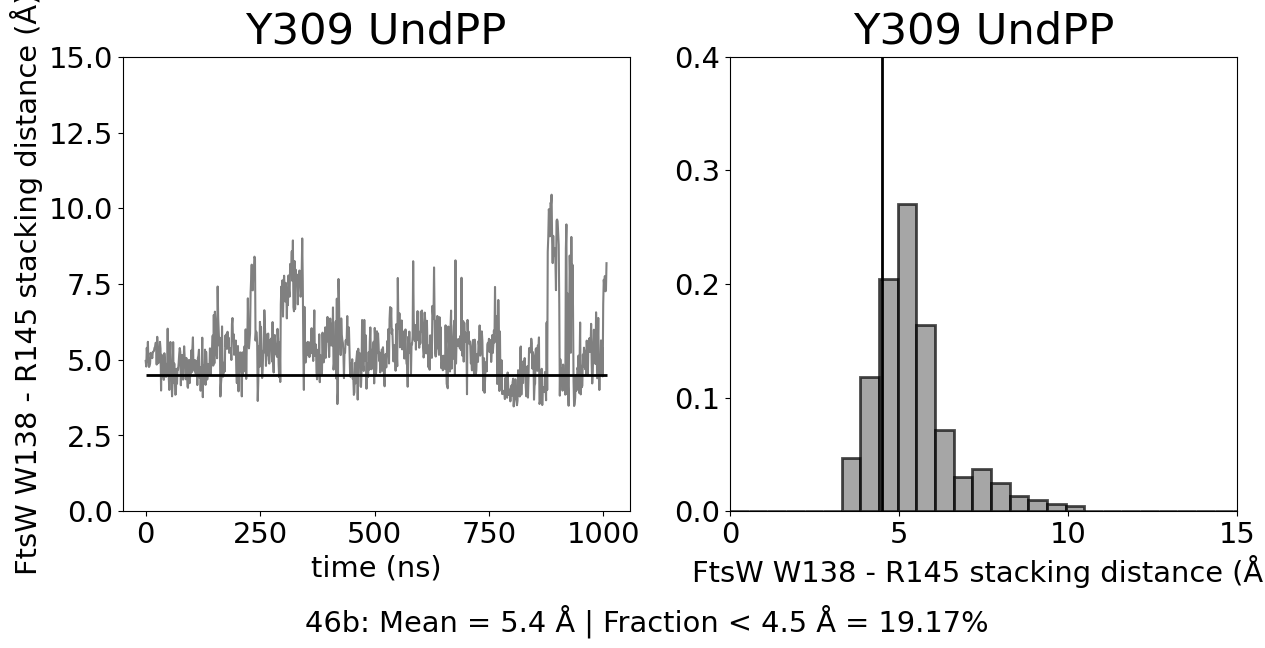

46c: Min = 3.2 Å | Frame 641/840 | Time 768.0 ns
46c: Mean = 5.4 Å | Fraction < 4.5 Å = 21.43%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\46c_noW_FtsW_W138-R145 stacking.png


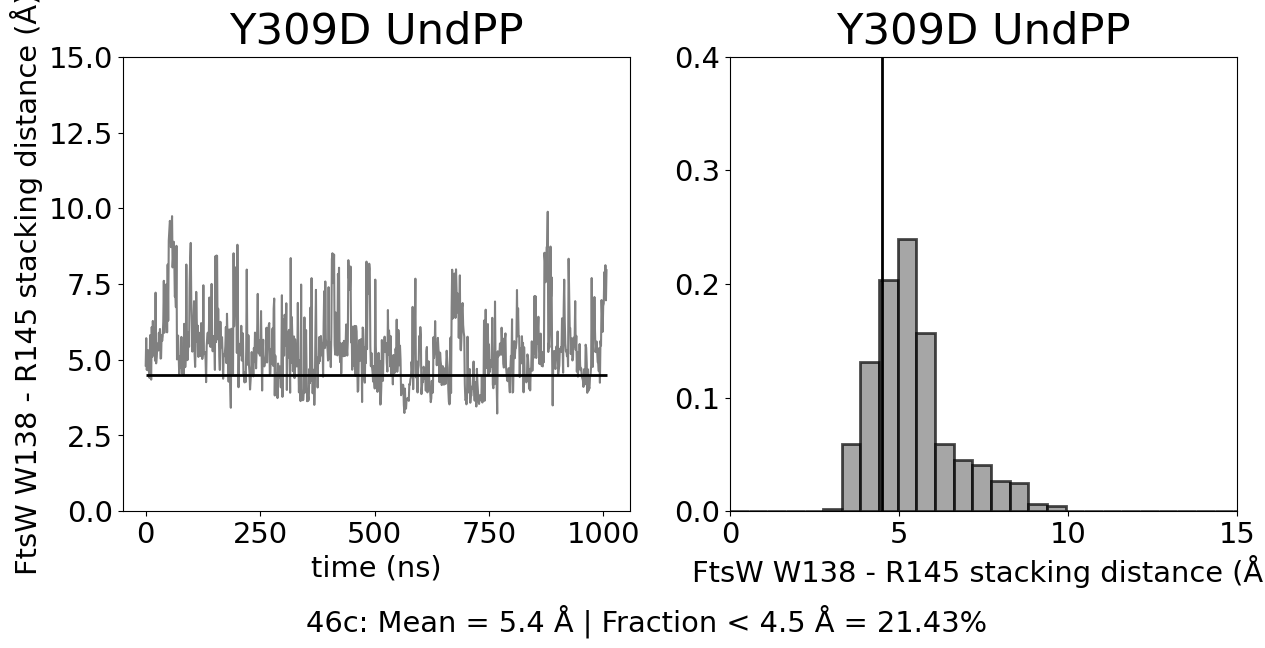

48: Min = 3.5 Å | Frame 25/420 | Time 28.8 ns
48: Mean = 5.1 Å | Fraction < 4.5 Å = 17.86%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\48_noW_FtsW_W138-R145 stacking.png


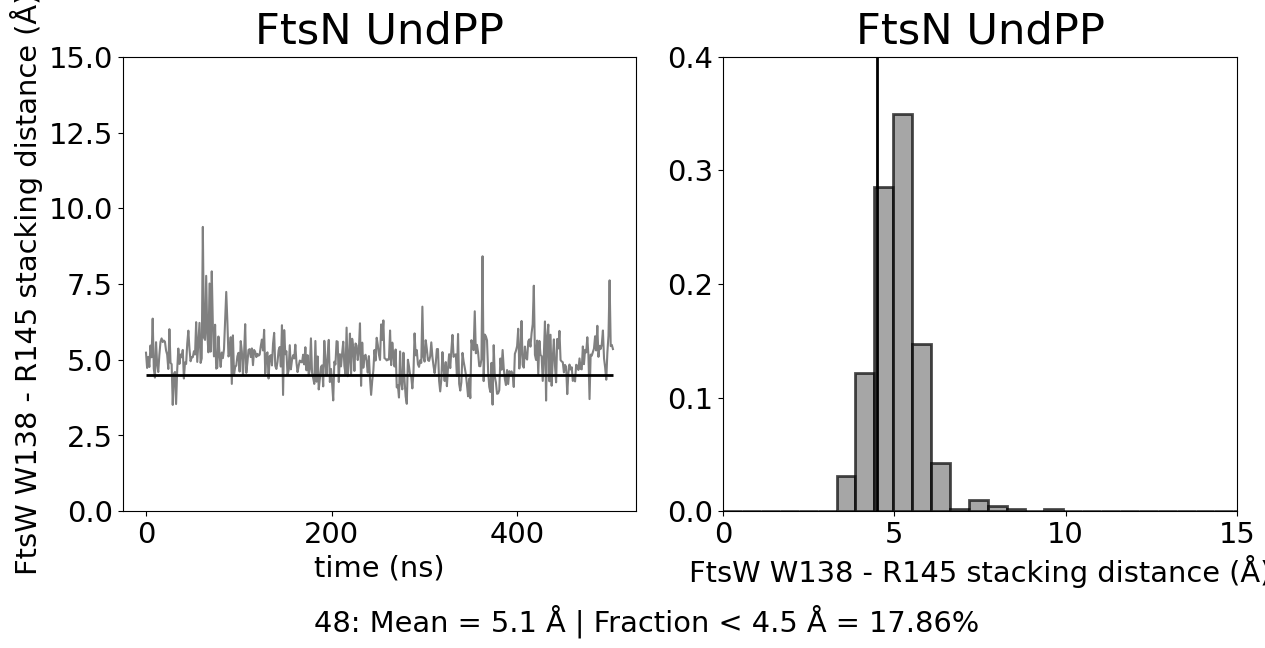

53: Min = 3.3 Å | Frame 575/840 | Time 688.8 ns
53: Mean = 5.9 Å | Fraction < 4.5 Å = 21.19%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\53_FtsW_W138-R145 stacking.png


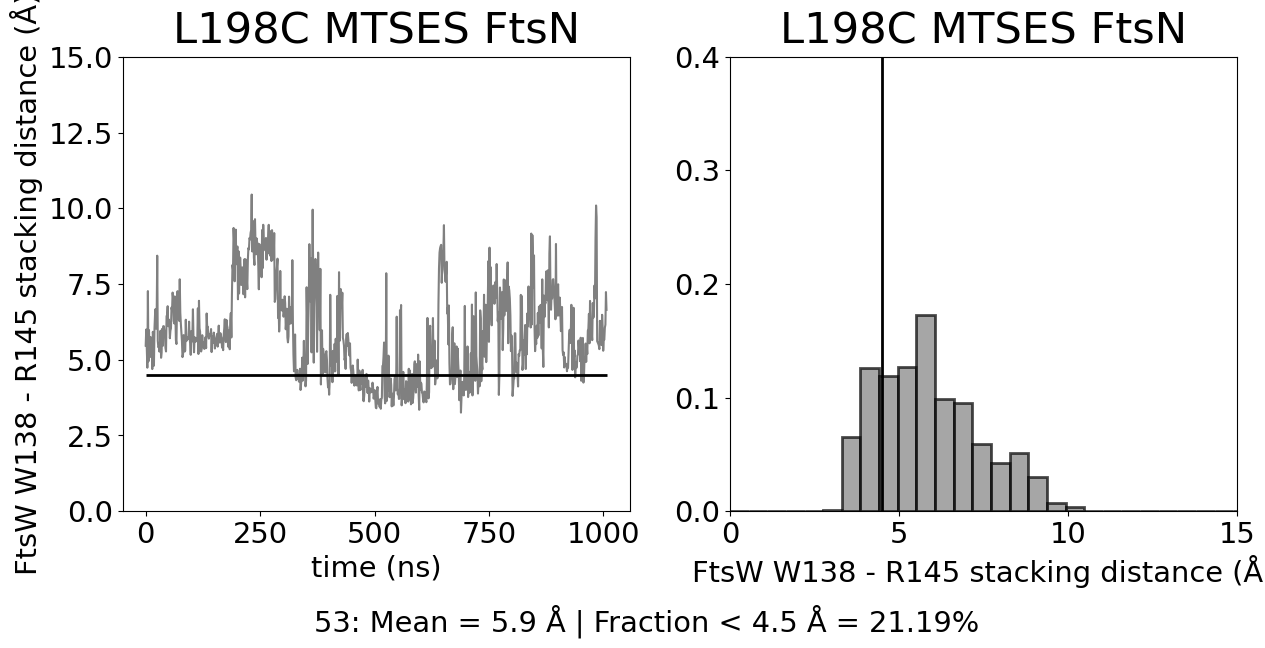

54: Min = 3.2 Å | Frame 487/830 | Time 583.1999999999999 ns
54: Mean = 4.2 Å | Fraction < 4.5 Å = 74.34%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\54_FtsW_W138-R145 stacking.png


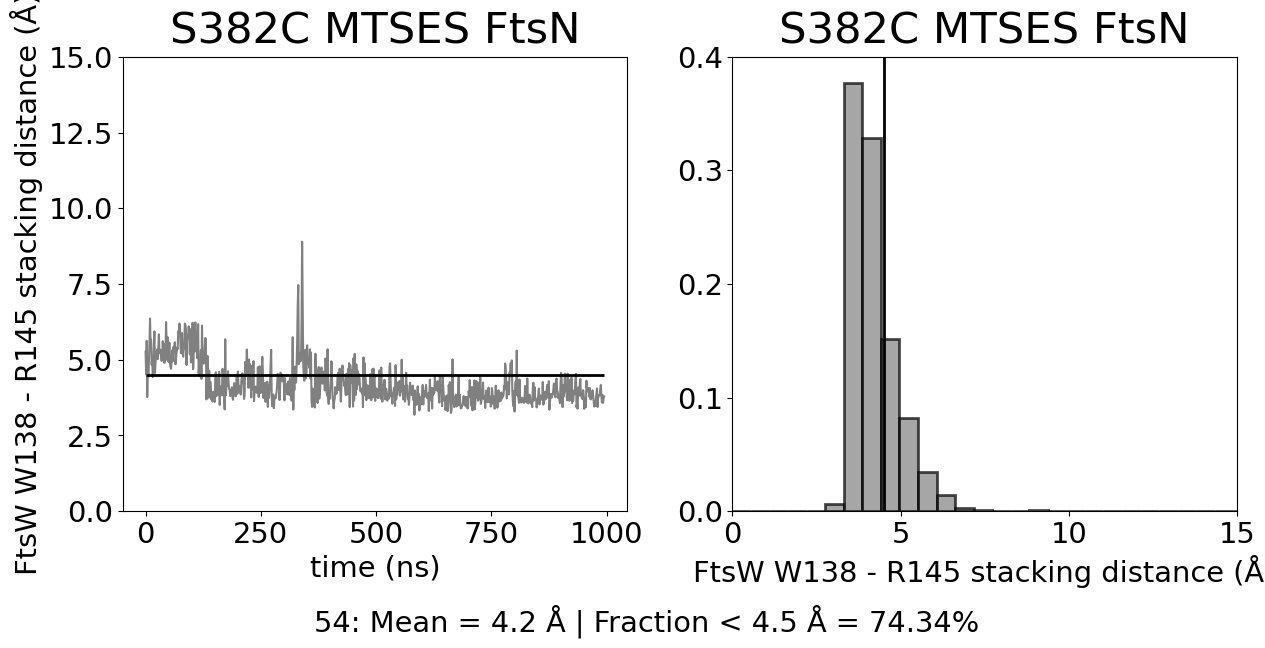

58: Min = 4.1 Å | Frame 115/840 | Time 136.79999999999998 ns
58: Mean = 5.7 Å | Fraction < 4.5 Å = 0.60%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\58_FtsW_W138-R145 stacking.png


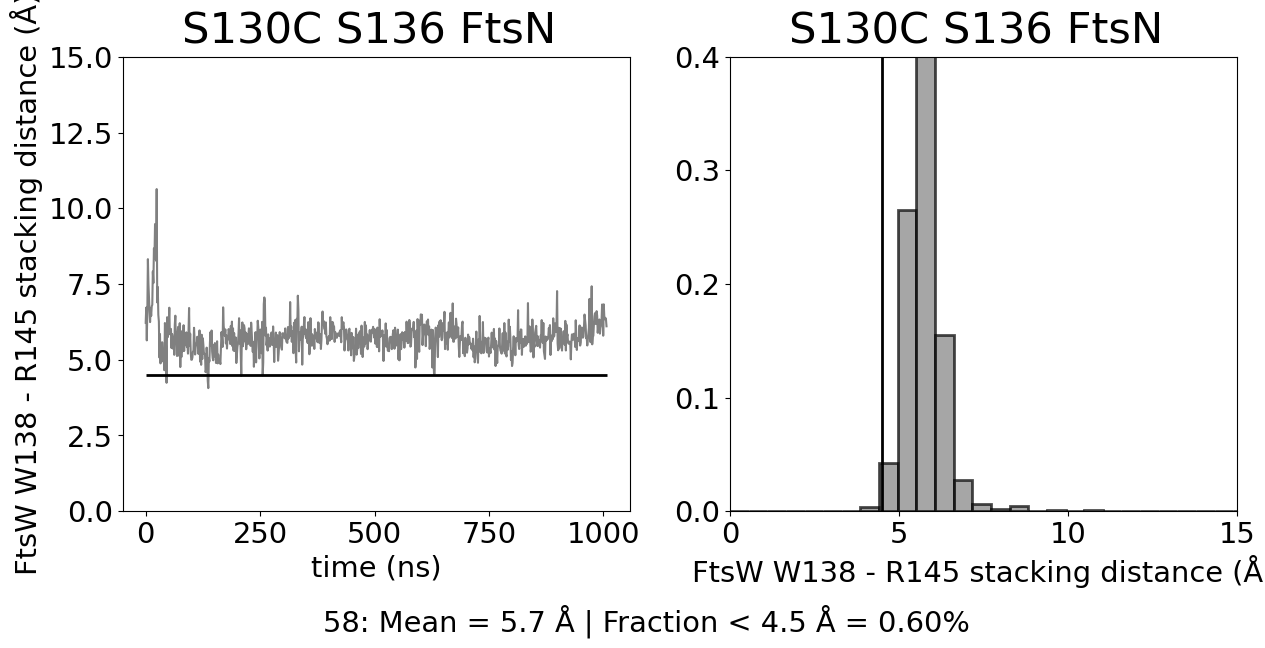

In [37]:
# Plotting (reads CSV cache)

style = cfg.plot_style

if style.var_name_plot is None:
    var_name_plot = cfg.var_name
else:
    var_name_plot = style.var_name_plot

for sim_number, csv_path in data_dict.items():
    try:
        m = sim_list.index(sim_number)
        sim_name = label_list[m]
    except ValueError:
        sim_name = sim_number

    plot_dist_time_trace_hist(
        csv_file=csv_path,
        var_name=var_name_plot,
        sim_name=sim_name,
        x_cutoff=cfg.x_cutoff,
        x_lim=(style.x_min_shared, style.x_max_shared) if style.share_lim else None,
        max_hist=style.max_hist,
        split_title=True,
        scale=style.scale,
    )


Wrote curated override: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\notebooks\curated\paper_main_FtsW_W138-R145 stacking.txt
Common end time (longest sim): 3970.80 ns
Saved combined contact summary to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_W138-R145 stacking\paper_main_ContactSummary_FtsW_W138-R145 stacking.png


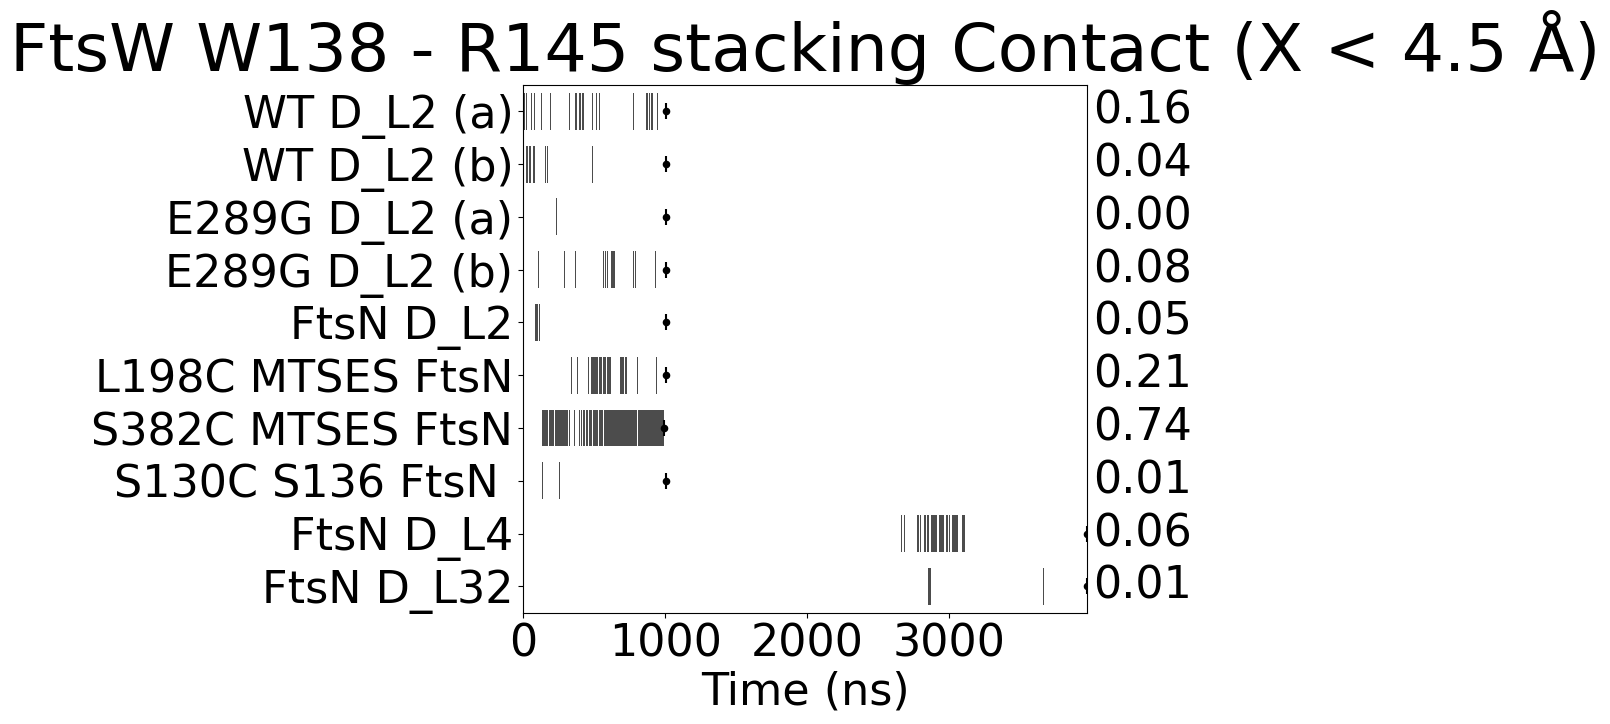

'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_W138-R145 stacking\\paper_main_ContactSummary_FtsW_W138-R145 stacking.png'

In [38]:
# Contact summary (curated list preset, per-variable override persisted if changed)

from curated_lists import (
    curated_list_with_optional_override,
    persist_per_variable_override_if_changed,
)
from contact_summary import ContactSummaryStyle, plot_contact_summary

PRESET_NAME = "paper_main"
CURATED_DIR = REPO_ROOT / "notebooks" / "curated"

# 1) Preset curated list (edit this list in the notebook)
DEFAULT_CURATED = ["14", "14b", "15", "15b", "17", "53", "54", "58"]

# 2) Optional per-variable override file
# If this file exists, it overrides DEFAULT_CURATED.
CURATED_FILE = CURATED_DIR / f"{PRESET_NAME}_{cfg.short_var_name}.txt"

summary_list = curated_list_with_optional_override(["14", "14b", "15", "15b", "17", "53", "54", "58", "42", "43"], CURATED_FILE)

# If you changed DEFAULT_CURATED in the notebook (or edited summary_list),
# persist that change for this variable only.
written = persist_per_variable_override_if_changed(
    default_sims=DEFAULT_CURATED,
    used_sims=summary_list,
    curated_dir=CURATED_DIR,
    short_var_name=cfg.short_var_name,
    preset_name=PRESET_NAME,
)
if written:
    print(f"Wrote curated override: {written}")

style = ContactSummaryStyle(scale=4.0, long_end=True, below_cutoff=True)

out_png = Path(cfg.out_dir) / f"{PRESET_NAME}_ContactSummary_{cfg.short_var_name}.png"

plot_contact_summary(
    data_dict=data_dict,
    out_png_path=str(out_png),
    var_name=cfg.var_name,
    x_cutoff=float(cfg.x_cutoff),
    summary_list=summary_list,
    sim_list=sim_list,
    label_list=label_list,
    num_to_label=None,
    style=style,
)
